In [ ]:

#El conjunto de datos de predicción de riesgo crediticio es un conjunto de datos totalmente sintético diseñado para simular un entorno real de préstamos financieros.
#El objetivo principal de este conjunto de datos es predecir si una solicitud de préstamo será aprobada basándose en la información demográfica, financiera y laboral del solicitante.
#Elegí este dataset ya que no se utilizaron datos financieros ni personales reales por lo que es seguro para fines educativos.

#!pip install scikit-learn

# Importamos librerías
import pandas as pd
import numpy as np
import statistics as sta
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import drive

# Monta drive
drive.mount('/content/drive')

# Ruta dentro del dataset
file_path = "drive/My Drive/Bocchio Monica - Comisión 26141 - TPI Machine Learning/dataset/loan_risk_prediction_dataset.csv"

# Cargamos el dataset directo a un DataFrame de Pandas
df = pd.read_csv(file_path)

Mounted at /content/drive


In [ ]:
# Análisis exploratorio dataset
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871,500.0,19,Female,High School,Chicago,Unemployed,0


In [ ]:
df.tail()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
4995,24,36780.0,23383,NaN,23,Male,Masters,Houston,Salaried,0
4996,66,99146.0,9760,306.0,14,Male,PhD,New York,Unemployed,0
4997,26,58100.0,18230,311.0,10,Female,High School,San Francisco,Self-Employed,0
4998,53,58513.0,12373,813.0,23,Male,PhD,Houston,Salaried,1
4999,36,58928.0,23615,648.0,10,Male,NaN,New York,Self-Employed,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   int64  
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 390.8+ KB


In [ ]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [ ]:
print(df.shape)

(5000, 10)


In [ ]:
print(df.columns)

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',
       'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved'],
      dtype='object')


In [ ]:
print(df.dtypes)

Age                  int64
Income             float64
LoanAmount           int64
CreditScore        float64
YearsExperience      int64
Gender              object
Education           object
City                object
EmploymentType      object
LoanApproved         int64
dtype: object


In [ ]:
#Calidad de datos dataset
#Nulos
#Income, CreditScore y Education tienen nulos
df.isnull().sum()

,0
Age,0
Income,196
LoanAmount,0
CreditScore,194
YearsExperience,0
Gender,0
Education,198
City,0
EmploymentType,0
LoanApproved,0


In [ ]:
#Calidad de datos dataset
#Duplicados
df.duplicated().sum()

np.int64(0)

In [ ]:
promedio = df["Income"].mean()
mediana = df["Income"].median()
moda = df["Income"].mode()[0]
dev_standard = df["Income"].std()

print(f"Promedio: {promedio}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")
print(f"Desviación Standard: {dev_standard}")

Promedio: 49738.12302248127
Mediana: 49488.0
Moda: 44576.0
Desviación Standard: 15101.361851274387


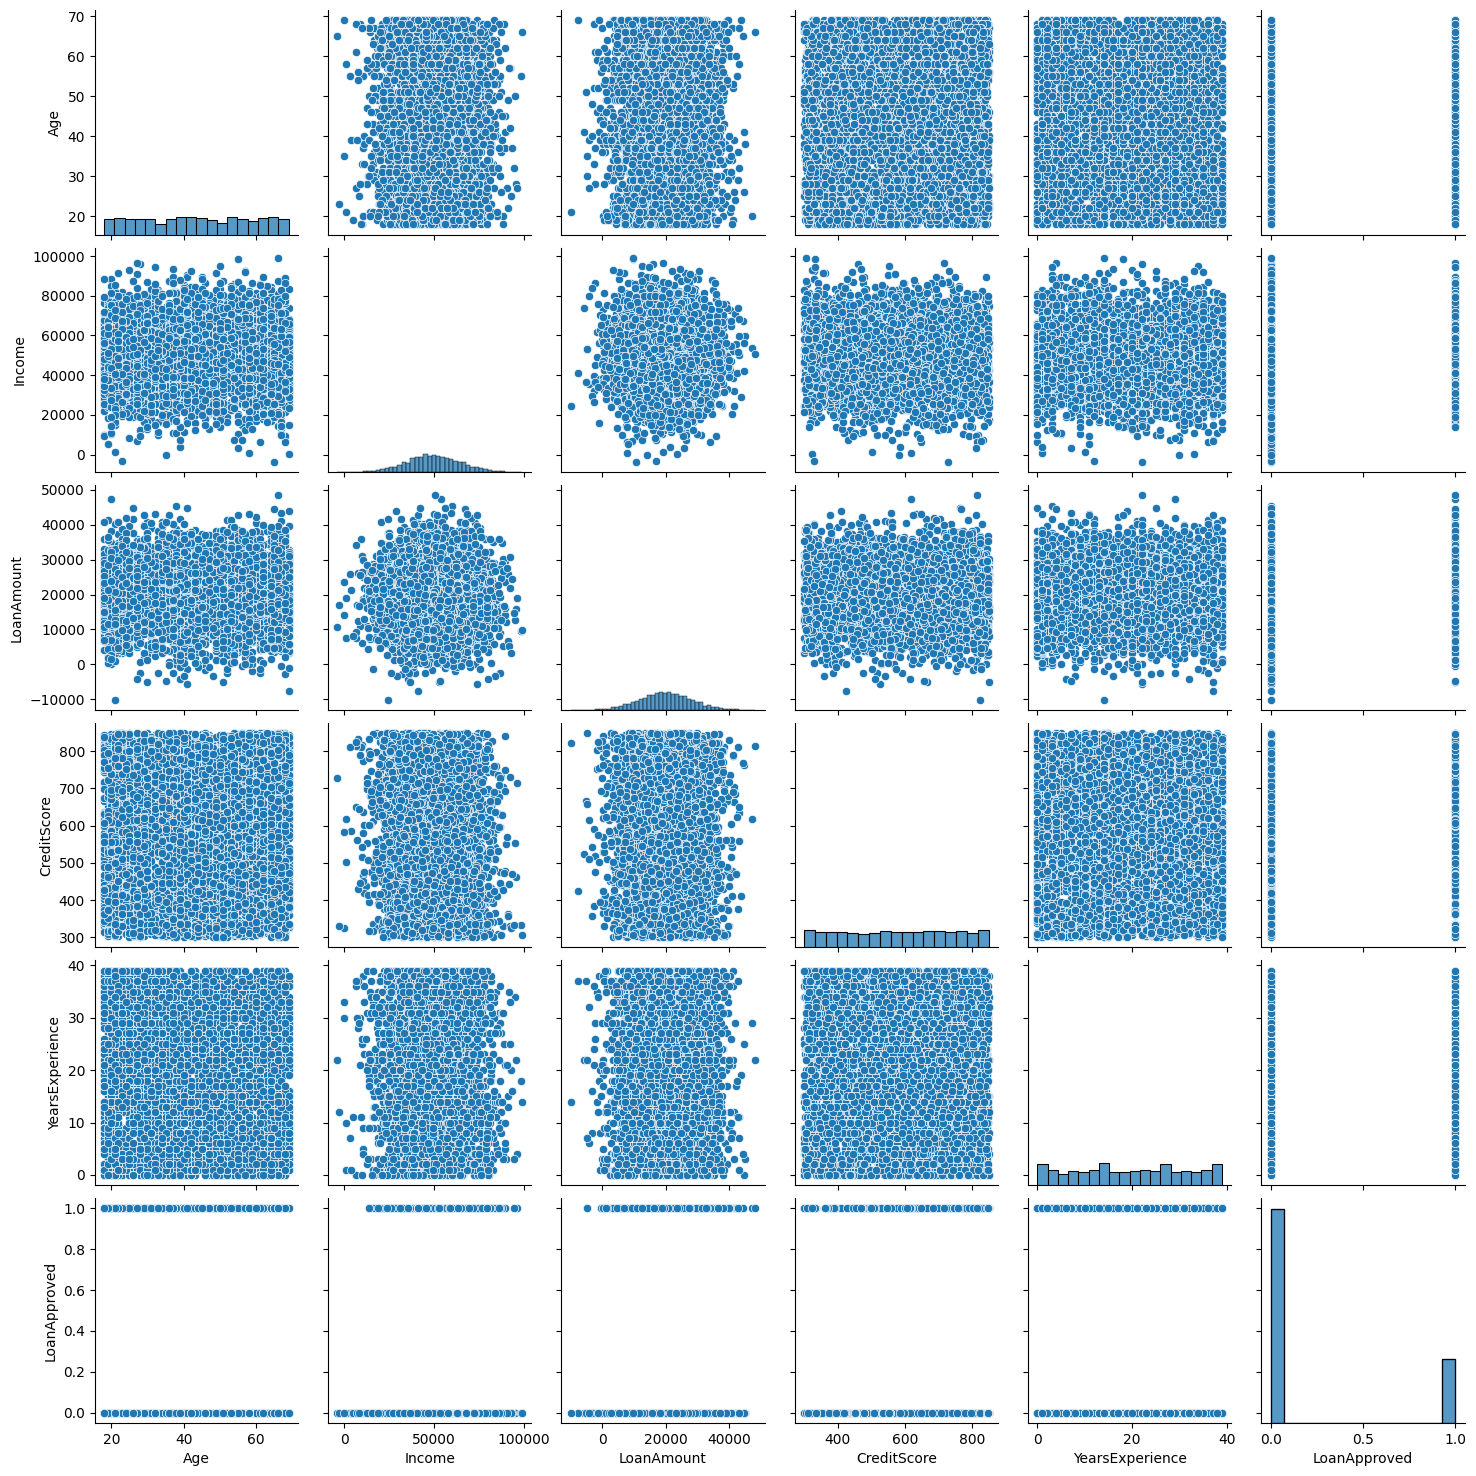

In [ ]:
#Gráfico dispersión cantidad y precio
#Importo librerías de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(df)
plt.show()

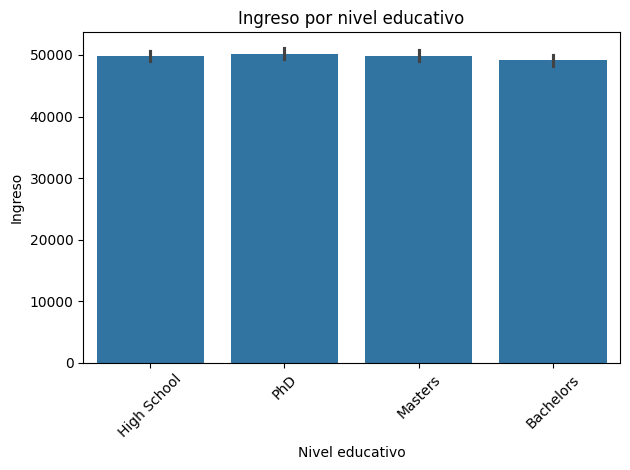

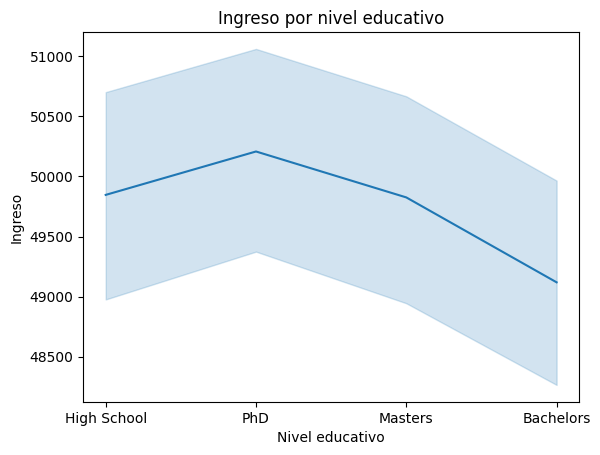

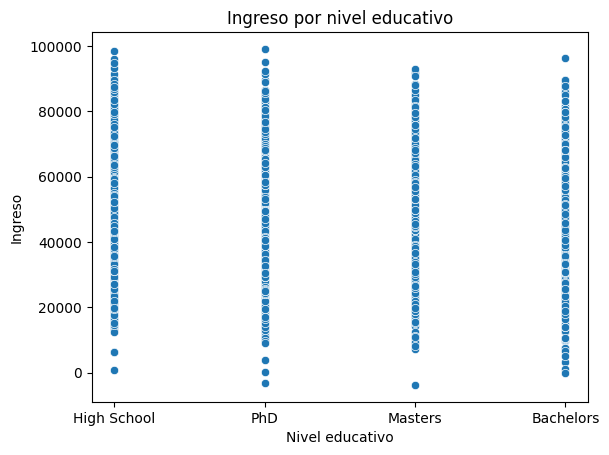

In [ ]:
#Importo librerías de gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#Gráfico de barras Ingreso por nivel educativo
fig_bar=sns.barplot(data=df, x='Education', y='Income')
plt.title('Ingreso por nivel educativo')
plt.xlabel('Nivel educativo')
plt.ylabel('Ingreso')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Gráfico de líneas Ingreso por nivel educativo
fig_line=sns.lineplot(data=df, x='Education', y='Income')
plt.title('Ingreso por nivel educativo')
plt.xlabel('Nivel educativo')
plt.ylabel('Ingreso')
plt.show()

#Gráfico de dispersión Ingreso por nivel educativo
fig_disp=sns.scatterplot(data=df, x='Education', y='Income')
plt.title('Ingreso por nivel educativo')
plt.xlabel('Nivel educativo')
plt.ylabel('Ingreso')
plt.show()

# Visualización de datos de Nivel educativo vs Ingreso
pie_data = df.reset_index()
fig_pie = px.pie(pie_data, template= "presentation",hole= 0.6,color_discrete_sequence=px.colors.sequential.RdBu)

# layout
fig_pie.update_layout(title_text='Distribución de Ingresos por Nivel educativo',title_x=0.5,font=dict(size=18),autosize=False,width=500,height=500,showlegend=False)
fig_pie.add_annotation(dict(x=0.5, y=0.5,  align='center',xref = "paper", yref = "paper",showarrow = False, font_size=22,text="<span style='font-size: 26px; color=#555; font-family:Arial'>Ingreso por Nivel Educativo<br></span>"))
fig_pie.update_traces(textposition='outside',  textinfo='percent+label', rotation=20)
fig_pie.show()

In [ ]:
#Dashboard
!pip install dash
import dash
from dash import dcc
from dash import html
import plotly.express as px

app = dash.Dash(__name__)

app.layout = html.Div(children=[
    html.H1(children='Dashboard'),
    dcc.Graph(
        id='Ingreso por Nivel educativo',
        figure=fig_bar
    ),
   dcc.Graph(
        id='Ingreso por Nivel educativo',
        figure=fig_pie
)
])

if __name__ == '__main__':
   app.run(debug=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 78.4 MB/s eta 0:00:00
Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: on


In [ ]:
df_modelo = df.copy()

df_modelo["EmploymentType_encoded"] = df_modelo["EmploymentType"].map({"Unemployed": 0, "Self-employed": 1, "Salaried":2})
df_modelo["Education_encoded"] = df_modelo["Education"].map({"Bachelors":0,"High School":1,"PhD":2,"Masters":3})
df_modelo["Gender_encoded"] = df_modelo["Gender"].map({"Male":0,"Female":1})

columnas = ['LoanApproved', 'Income', 'EmploymentType_encoded', 'Age', 'Education_encoded', 'Gender_encoded', 'CreditScore']
df_modelo = df_modelo[columnas].dropna()


X = df_modelo[['Income','EmploymentType_encoded','Age','Education_encoded','Gender_encoded','CreditScore']]
Y = df_modelo['LoanApproved']


print(f"Nos quedaron {len(df_modelo)} préstamos listos para el entrenamiento")

Nos quedaron 2881 préstamos listos para el entrenamiento


Datos para entrenar: 2304 préstamos
Datos para prueba: 577 préstamos
Precisión en cada partición (Cross-Validation): [0.90889371 0.92624729 0.9175705  0.92190889 0.91304348]
Precisión media: 0.9175
Precisión en el conjunto de prueba (Test Set): 0.8995


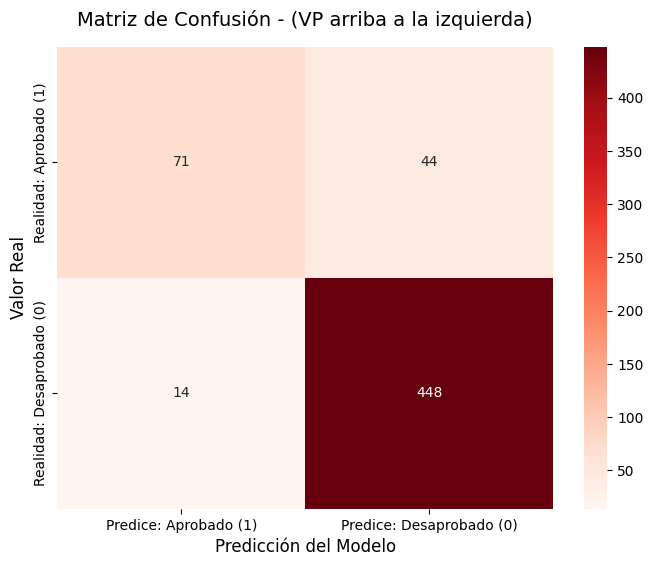

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression

# Elegí modelo de regresión logística
# porque la variable objetivo es aprobación de crédito
# que es binaria (1: aprobado, 0: desaprobado)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Dividiendo los datos en 80% para entrenar y 20% para testear
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Datos para entrenar: {X_train.shape[0]} préstamos")
print(f"Datos para prueba: {X_test.shape[0]} préstamos")

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Definir los pasos del flujo
pipeline_modelo = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Paso 1: Rellenar nulos con el promedio
    ('scaler', StandardScaler()),                 # Paso 2: Escalar datos
    ('classifier', LogisticRegression())      # Paso 3: Modelo
])

# Entrenamos el pipeline completo
pipeline_modelo.fit(X_train, y_train)

# Realizamos predicciones sobre datos nuevos
predicciones = pipeline_modelo.predict(X_test)

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Evaluar el modelo utilizando Validación Cruzada
puntajes = cross_val_score(pipeline_modelo, X_train, y_train, cv=5, scoring='accuracy')

print(f"Precisión en cada partición (Cross-Validation): {puntajes}")
print(f"Precisión media: {puntajes.mean():.4f}")

# Evaluar de forma final contra el conjunto de prueba
precision_final = pipeline_modelo.score(X_test, y_test)
print(f"Precisión en el conjunto de prueba (Test Set): {precision_final:.4f}")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Para la Matriz de confusión

# Calculamos la matriz forzando el orden para que los VP queden arriba a la izquierda
# (1: Crédito aprobado, 0: Crédito desaprobado)
cm_completo = confusion_matrix(y_test, predicciones, labels=[1, 0])

# Creamos la visualización con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_completo, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predice: Aprobado (1)', 'Predice: Desaprobado (0)'],
            yticklabels=['Realidad: Aprobado (1)', 'Realidad: Desaprobado (0)'])

# Configuramos los títulos
plt.title('Matriz de Confusión - (VP arriba a la izquierda)', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)

plt.show()


#La precisión y la Matriz de confusión dieron buenos resultados
#Podría ser de utilidad para analizar el riesgo crediticio con datos reales